## Loading dataset

In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

import nltk

In [ ]:
import pandas as pd

df = pd.read_csv(
    "dataset/untidar_abstrak_perkalimat_clean_baseline.csv",
    sep="|"
)

# penambahan ID kalimat dan set index untuk menghemat memori
df.insert(
    0,
    "kalimat_id",
    [f"S{i:07d}" for i in range(1, len(df) + 1)]
)

df.head()

,kalimat_id,Kalimat,Tahun,Judul,Penulis,Jurusan,Fakultas,Lang,word_count,n_words,n_syll,n_sent,words_per_sent,syll_per_word
0,S0000001,Penelitian variasi bahasa pada lanskap linguis...,2024,SKRIPSI VARIASI BAHASA PADA LANSKAP DI SEKITAR...,PRASASTI LISHERNANDA PUTRI,S1 PENDIDIKAN BAHASA DAN SASTRA INDONESIA,FKIP,ID,22,22,57,1,22.0,2.590909
1,S0000002,Adanya variasi bahasa tidak menghilangkan fung...,2024,SKRIPSI VARIASI BAHASA PADA LANSKAP DI SEKITAR...,PRASASTI LISHERNANDA PUTRI,S1 PENDIDIKAN BAHASA DAN SASTRA INDONESIA,FKIP,ID,9,9,24,1,9.0,2.666667
2,S0000003,Lanskap linguistik memberikan informasi kepada...,2024,SKRIPSI VARIASI BAHASA PADA LANSKAP DI SEKITAR...,PRASASTI LISHERNANDA PUTRI,S1 PENDIDIKAN BAHASA DAN SASTRA INDONESIA,FKIP,ID,11,11,29,1,11.0,2.636364
3,S0000004,Penelitian ini bertujuan untuk (1) menemukan b...,2024,SKRIPSI VARIASI BAHASA PADA LANSKAP DI SEKITAR...,PRASASTI LISHERNANDA PUTRI,S1 PENDIDIKAN BAHASA DAN SASTRA INDONESIA,FKIP,ID,26,26,60,1,26.0,2.307692
4,S0000005,Penelitian ini menggunakan metode kualitatif d...,2024,SKRIPSI VARIASI BAHASA PADA LANSKAP DI SEKITAR...,PRASASTI LISHERNANDA PUTRI,S1 PENDIDIKAN BAHASA DAN SASTRA INDONESIA,FKIP,ID,8,8,24,1,8.0,3.000000


In [58]:
# Menyimpan DataFrame ke file CSV baru
new_csv_path = "dataset/untidar_abstrak_perkalimat_clean_readability.csv"
df.to_csv(new_csv_path, sep="|", index=False)
print(f"DataFrame berhasil disimpan ke: {new_csv_path}")

# Menampilkan bentuk DataFrame
print("\n=== Bentuk DataFrame ===")
print(df.shape)

# Menampilkan informasi kolom dan tipe data
print("\n=== Informasi DataFrame ===")
df.info()

# Menampilkan jumlah nilai null
print("\n=== Jumlah Nilai Null (Missing Values) ===")
print(df.isnull().sum())


DataFrame berhasil disimpan ke: dataset/untidar_abstrak_perkalimat_clean_readability.csv

=== Bentuk DataFrame ===
(27274, 21)

=== Informasi DataFrame ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27274 entries, 0 to 27273
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   kalimat_id       27274 non-null  object 
 1   Kalimat          27274 non-null  object 
 2   Tahun            27274 non-null  int64  
 3   Judul            27274 non-null  object 
 4   Penulis          27260 non-null  object 
 5   Jurusan          27237 non-null  object 
 6   Fakultas         27179 non-null  object 
 7   Lang             27274 non-null  object 
 8   word_count       27274 non-null  int64  
 9   n_words          27274 non-null  int64  
 10  n_syll           27274 non-null  int64  
 11  n_sent           27274 non-null  int64  
 12  words_per_sent   27274 non-null  float64
 13  syll_per_word    27274 non-null  float64

## EDA Dataset 

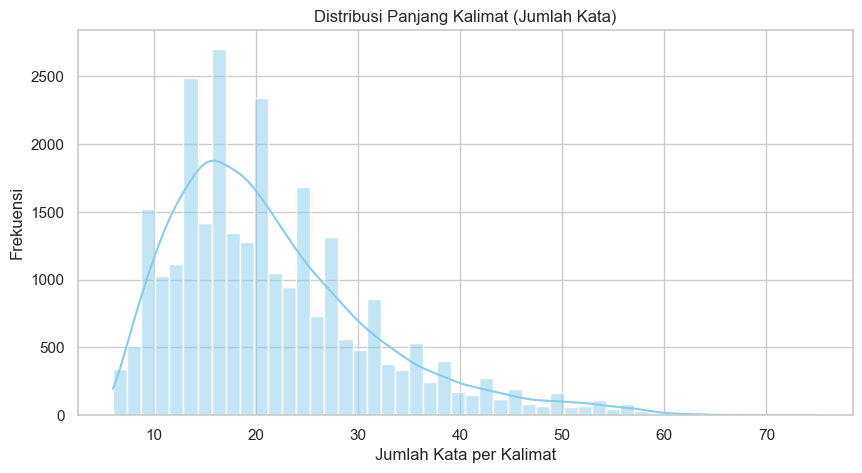

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.histplot(df["n_words"], bins=50, kde=True, color="skyblue")

plt.title("Distribusi Panjang Kalimat (Jumlah Kata)")
plt.xlabel("Jumlah Kata per Kalimat")
plt.ylabel("Frekuensi")
plt.show()

In [61]:
# Filter kalimat yang memiliki lebih dari 50 kata
kalimat_panjang = df[df["n_words"] > 40][["kalimat_id", "Kalimat", "n_words"]]

# 1. Tampilkan total jumlah kalimat yang memenuhi kriteria
print(f"Total kalimat dengan > 50 kata: {len(kalimat_panjang)}")

# 2. Tampilkan 10 contoh kalimat teratas
display(kalimat_panjang.head(10))

# 3. Simpan hasil ke CSV
kalimat_panjang.to_csv("dataset/benchmark/kalimat_panjang_review.csv", index=False)



Total kalimat dengan > 50 kata: 1503


,kalimat_id,Kalimat,n_words
32,S0000033,Variabel yang digunakan merupakan data jumlah ...,41
35,S0000036,Hal ini dapat dilihat dari rata-rata nilai err...,44
39,S0000040,Kesimpulan dari penelitian ini dimana pengguna...,44
45,S0000046,Perencanaan ini dilakukan dengan tujuan untuk ...,43
49,S0000050,Daya pompa yang dibutuhkan meliputi daya pompa...,50
62,S0000063,Pengaplikasian pada kandang peternakan ayam di...,45
105,S0000106,Hasil dari penelitian diperoleh total kebutuha...,52
135,S0000136,Layanan download dengan nilai parameter packet...,46
162,S0000163,Hasil analisis karakteristik parkir menunjukan...,42
167,S0000168,Penelitian ini dilaksanakan dengan melakukan a...,46


In [51]:
# Vocab size, kata unik
import re

all_words = []

for text in df["Kalimat"].dropna():
    words = re.findall(r'\w+', str(text).lower())
    all_words.extend(words)

vocab = set(all_words)

print("=== VOCABULARY SIZE ===")
print(f"Total kata unik (vocab size): {len(vocab)}")

=== VOCABULARY SIZE ===
Total kata unik (vocab size): 21767


C:\Users\Danang ARA\AppData\Local\Temp\ipykernel_21608\1409544310.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(words), palette="viridis")


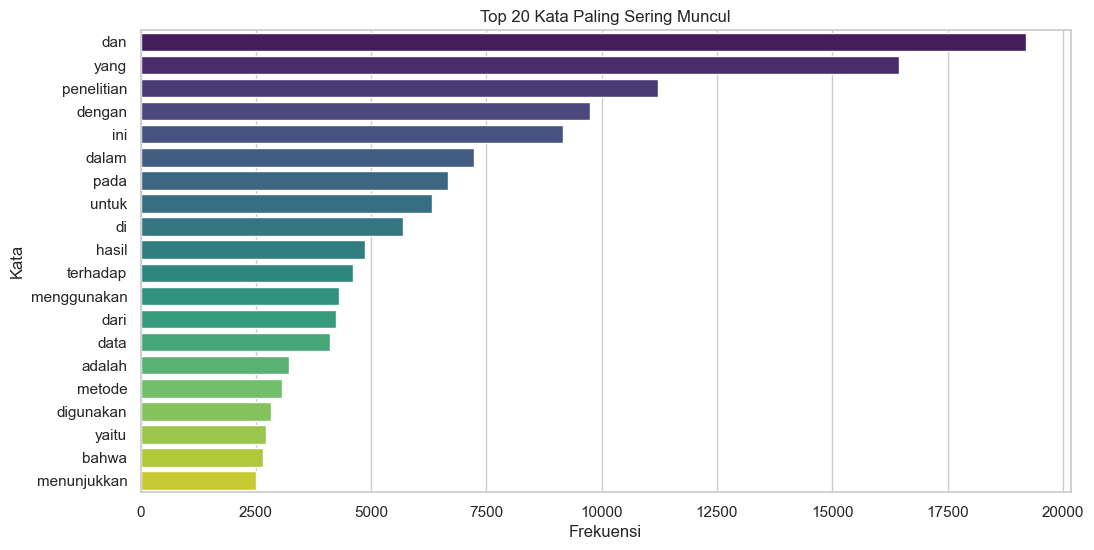

In [ ]:
# Top N word by frekuensinya
from collections import Counter

word_freq = Counter(all_words)

top_n = 20
top_words = word_freq.most_common(top_n)

words, counts = zip(*top_words)

plt.figure(figsize=(12,6))
sns.barplot(x=list(counts), y=list(words), palette="viridis")

plt.title(f"Top {top_n} Kata Paling Sering Muncul")
plt.xlabel("Frekuensi")
plt.ylabel("Kata")
plt.show()

In [53]:
# Stopword vs non Stopword
import nltk
from nltk.corpus import stopwords

try:
    stop_words = set(stopwords.words("indonesian"))
except:
    nltk.download("stopwords")
    stop_words = set(stopwords.words("indonesian"))

stop_count = 0
non_stop_count = 0

for w in all_words:
    if w in stop_words:
        stop_count += 1
    else:
        non_stop_count += 1

print("=== STOPWORD ANALYSIS ===")
print(f"Stopwords     : {stop_count}")
print(f"Non-stopwords : {non_stop_count}")
print(f"Rasio         : {non_stop_count/(stop_count+non_stop_count):.3f}")

=== STOPWORD ANALYSIS ===
Stopwords     : 192859
Non-stopwords : 398793
Rasio         : 0.674


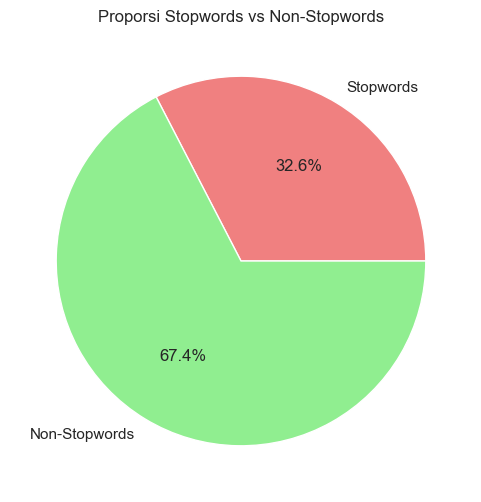

In [54]:
# Visualisasi Proporsi
plt.figure(figsize=(6,6))
plt.pie(
    [stop_count, non_stop_count],
    labels=["Stopwords", "Non-Stopwords"],
    autopct="%1.1f%%",
    colors=["lightcoral", "lightgreen"]
)

plt.title("Proporsi Stopwords vs Non-Stopwords")
plt.show()

## EDA Kompleksitas kalimat per Fakultas

C:\Users\Danang ARA\AppData\Local\Temp\ipykernel_21608\1341681042.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Danang ARA\AppData\Local\Temp\ipykernel_21608\1341681042.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Danang ARA\AppData\Local\Temp\ipykernel_21608\1341681042.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


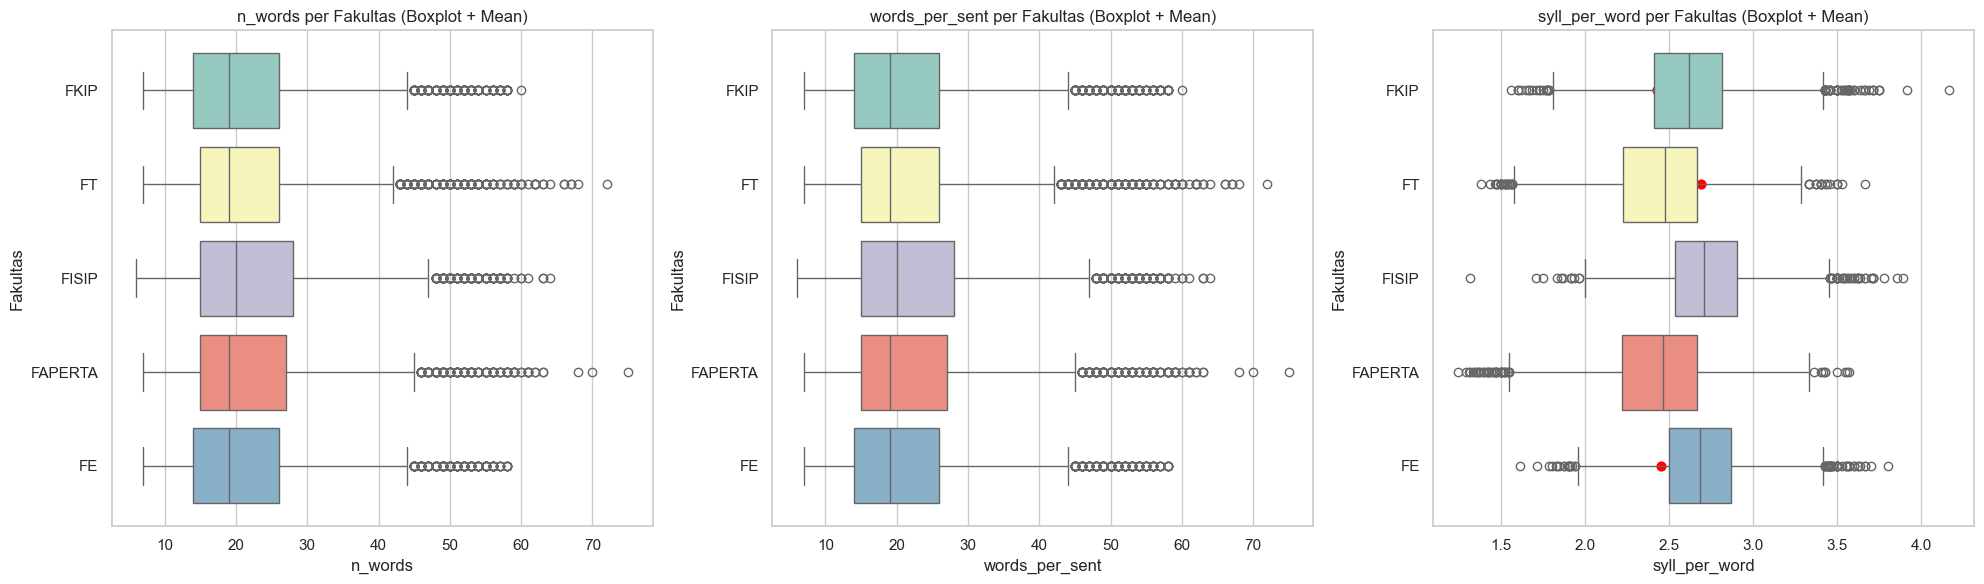

In [33]:
# Distribusi Kompleksitas Kalimat
import numpy as np
from scipy import stats
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import string
from collections import Counter
import nltk
from nltk.corpus import stopwords
sns.set(style="whitegrid")

 
# statistik kompleksitas fakultas
def compute_stats(group):
    return pd.Series({
        "mean": group.mean(),
        "median": group.median(),
        "mode": stats.mode(group, keepdims=True).mode[0],
        "std": group.std()
    })

# aplikasi ke fitur linguistik
stats_nwords = df.groupby("Fakultas")["n_words"].apply(compute_stats).unstack()
stats_nwords

stats_wps = df.groupby("Fakultas")["words_per_sent"].apply(compute_stats).unstack()
stats_wps

stats_spw = df.groupby("Fakultas")["syll_per_word"].apply(compute_stats).unstack()
stats_spw

# visualisasi
fig, ax = plt.subplots(1, 3, figsize=(20, 6))

features = ["n_words", "words_per_sent", "syll_per_word"]
colors = ["skyblue", "orange", "green"]

for i, feat in enumerate(features):
    sns.boxplot(
        y="Fakultas",
        x=feat,
        data=df,
        ax=ax[i],
        palette="Set3"
    )

    # mean overlay
    means = df.groupby("Fakultas")[feat].mean()
    for j, val in enumerate(means):
        ax[i].scatter(val, j, color="red", s=40)

    ax[i].set_title(f"{feat} per Fakultas (Boxplot + Mean)")

plt.tight_layout()
plt.show()

In [34]:
# Summary Group per fakultas
summary = df.groupby("Fakultas")[[
    "n_words",
    "words_per_sent",
    "syll_per_word"
]].agg(["mean", "median", "std"])

summary

n_words                   words_per_sent                    \
               mean median        std           mean median        std   
Fakultas                                                                 
FAPERTA   22.104231   19.0  10.796074      22.104231   19.0  10.796074   
FE        20.753048   19.0   9.070437      20.753048   19.0   9.070437   
FISIP     22.259729   20.0  10.407482      22.259729   20.0  10.407482   
FKIP      21.033785   19.0   9.505090      21.033785   19.0   9.505090   
FT        21.836302   19.0  10.175424      21.836302   19.0  10.175424   

         syll_per_word                      
                  mean    median       std  
Fakultas                                    
FAPERTA       2.425474  2.461538  0.347181  
FE            2.690567  2.681818  0.273102  
FISIP         2.715795  2.705882  0.273756  
FKIP          2.617777  2.615385  0.304009  
FT            2.449073  2.473684  0.338479

In [40]:
# Fakultas paling “complex writing”
df.groupby("Fakultas")["words_per_sent"].mean().sort_values(ascending=False)

Fakultas
FISIP      22.259729
FAPERTA    22.104231
FT         21.836302
FKIP       21.033785
FE         20.753048
Name: words_per_sent, dtype: float64

In [ ]:
# Fakultas paling “dense lexical”
df.groupby("Fakultas")["syll_per_word"].mean().sort_values(ascending=False)

Fakultas
FISIP      2.715795
FE         2.690567
FKIP       2.617777
FT         2.449073
FAPERTA    2.425474
Name: syll_per_word, dtype: float64

In [41]:
df.groupby("Fakultas")["n_words"].describe()

,count,mean,std,min,25%,50%,75%,max
Fakultas,,,,,,,,
FAPERTA,3262.0,22.104231,10.796074,7.0,15.0,19.0,27.0,75.0
FE,6726.0,20.753048,9.070437,7.0,14.0,19.0,26.0,58.0
FISIP,5756.0,22.259729,10.407482,6.0,15.0,20.0,28.0,64.0
FKIP,6719.0,21.033785,9.505090,7.0,14.0,19.0,26.0,60.0
FT,4716.0,21.836302,10.175424,7.0,15.0,19.0,26.0,72.0


## Kalkulasi Target Keterbacaan

In [25]:
# kalkulasi Flesch Gunning Fog dan SMOG Index
import re
import numpy as np

# supaya cocok untuk Bahasa Indonesia pakai syllable approx karena adaptasi bahasa di keterangan
def count_syllables(word):
    word = word.lower()
    word = re.sub(r'[^a-z]', '', word)

    vowels = "aiueo"
    count = 0
    prev_vowel = False

    for char in word:
        if char in vowels:
            if not prev_vowel:
                count += 1
                prev_vowel = True
        else:
            prev_vowel = False

    return max(count, 1)

# ekstraksi metrik
def extract_metrics(text):
    words = re.findall(r'\w+', str(text).lower())
    sentences = re.split(r'[.!?]', str(text))

    words = [w for w in words if w.isalpha()]
    n_words = len(words)
    n_sent = max(len([s for s in sentences if s.strip()]), 1)

    syllables = sum(count_syllables(w) for w in words)

    # complex words (Gunning Fog)
    complex_words = len([w for w in words if count_syllables(w) >= 3])

    return n_words, n_sent, syllables, complex_words


# pengaplikasian ke dataframe
results = df["Kalimat"].apply(extract_metrics)

df[["n_words_calc", "n_sent_calc", "n_syll_calc", "n_complex_words"]] = list(results)


# Formulasi Flesch FRE
df["flesch"] = (
    206.835
    - 1.015 * (df["n_words_calc"] / df["n_sent_calc"])
    - 84.6 * (df["n_syll_calc"] / df["n_words_calc"])
)

# Formulasi Gunning Fog
df["gunning_fog"] = 0.4 * (
    (df["n_words_calc"] / df["n_sent_calc"]) +
    100 * (df["n_complex_words"] / df["n_words_calc"])
)

# Formulasi SMOG INDEX
df["smog"] = (
    1.043 * np.sqrt(
        df["n_complex_words"] * (30 / df["n_sent_calc"])
    )
    + 3.1291
)

# final dataframe 1
df[[
    "Kalimat",
    "n_words_calc",
    "n_sent_calc",
    "n_syll_calc",
    "n_complex_words",
    "flesch",
    "gunning_fog",
    "smog"
]].head()

,Kalimat,n_words_calc,n_sent_calc,n_syll_calc,n_complex_words,flesch,gunning_fog,smog
0,Penelitian variasi bahasa pada lanskap linguis...,22,1,57,10,-34.685909,26.981818,21.194390
1,Adanya variasi bahasa tidak menghilangkan fung...,9,1,24,5,-27.900000,25.822222,15.903189
2,Lanskap linguistik memberikan informasi kepada...,11,1,29,6,-27.366364,26.218182,17.122413
3,Penelitian ini bertujuan untuk (1) menemukan b...,24,1,58,10,-21.975000,26.266667,21.194390
4,Penelitian ini menggunakan metode kualitatif d...,8,1,24,5,-55.085000,28.200000,15.903189


Flesch Reading Ease aslinya memang dirancang untuk bahasa Inggris, dengan formula berbasis jumlah kata per kalimat dan jumlah suku kata per kata. Nah, ketika dipakai untuk Bahasa Indonesia, ada masalah:

1. Bahasa Indonesia lebih silabik (kata-kata cenderung panjang, banyak vokal), sehingga hitungan suku kata jadi lebih krusial daripada sekadar jumlah huruf.
2. Formula asli Flesch bisa bias kalau langsung diterapkan, karena distribusi kata dan struktur morfologi Indonesia berbeda dari bahasa Inggris. Misalnya, kata "kemerdekaan" punya 5 suku kata, tapi panjang hurufnya tidak sebanding dengan kata Inggris yang kompleks.
3. Approximation syllable count (perkiraan jumlah suku kata) dipakai supaya aman, karena algoritma otomatis sering kesulitan mendeteksi suku kata Indonesia dengan akurat (misalnya diftong, konsonan rangkap, atau kata serapan). Dengan pendekatan aproksimasi, kita bisa menjaga konsistensi skor tanpa harus bergantung pada segmentasi fonetik yang rumit.

mengapa pakai 3 formula sekaligus ?



1. Flesch Reading Ease 

$$\text{Flesch Reading Ease } = 206.835 - 1.015 \cdot \frac{\text{words}}{\text{sentences}} - 84.6 \cdot \frac{\text{syllables}}{\text{words}}$$

- Kelebihan:
	1. paling populer di NLP & education research
	2. stabil untuk general text
	3. gampang di-interpret
- Kekurangan:
	1. kurang sensitif untuk teks akademik Indonesia
	2. tidak eksplisit “complex words”


2. Gunning Fog Index

$$\text{Gunning Fog Index} = 0.4 \cdot \left[ \left( \frac{\text{words}}{\text{sentences}} \right) + 100 \cdot \left( \frac{\text{complex words}}{\text{words}} \right) \right]$$

- Kelebihan:
	1. sangat bagus untuk academic writing
	2. fokus ke “complex words”
	3. lebih cocok untuk skripsi, jurnal, abstrak
- Kekurangan:
	1. butuh definisi “complex word” (>= 3 syllables)
	2. agak noisy untuk Bahasa Indonesia


3. SMOG Index

$$\text{Gunning Fog Index} = 0.4 \cdot \left[ \left( \frac{\text{words}}{\text{sentences}} \right) + 100 \cdot \left( \frac{\text{complex words}}{\text{words}} \right) \right]$$

- Kelebihan:
	1. sangat kuat untuk formal text
	2. stabil di domain akademik
	3. Fokus ke polysyllabic words
- Kekurangan:
	1. kurang cocok untuk kalimat pendek (dataset sentence-level)




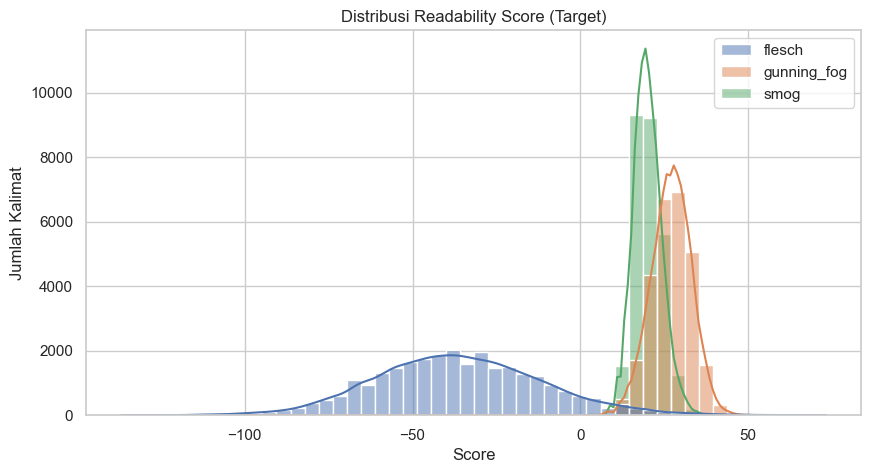

In [ ]:
# Distribusi Target (3 Grafik Berbeda yang dioverlay)

# ===== DESKRIPSI STATISTIK (Target Readability Scores) =====
print("Deskripsi Statistik Readability Scores:")
display(df[["flesch", "gunning_fog", "smog"]].describe())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Plot Flesch
sns.histplot(df["flesch"], bins=50, kde=True, ax=axes[0], color="purple")
axes[0].set_title("Distribusi Flesch Reading Ease")
axes[0].set_xlabel("Score")
axes[0].set_ylabel("Jumlah Kalimat")

# 2. Plot Gunning Fog
sns.histplot(df["gunning_fog"], bins=50, kde=True, ax=axes[1], color="teal")
axes[1].set_title("Distribusi Gunning Fog Index")
axes[1].set_xlabel("Score")
axes[1].set_ylabel("Jumlah Kalimat")

# 3. Plot SMOG
sns.histplot(df["smog"], bins=50, kde=True, ax=axes[2], color="coral")
axes[2].set_title("Distribusi SMOG Index")
axes[2].set_xlabel("Score")
axes[2].set_ylabel("Jumlah Kalimat")

plt.tight_layout()
plt.show()

Deskripsi Statistik Readability Scores:


,flesch,gunning_fog,smog
count,27274.000000,27274.000000,27274.000000
mean,-36.144871,27.038439,19.992232
std,24.890144,5.949543,4.225211
min,-136.695000,2.000000,3.129100
25%,-53.062069,23.200000,17.122413
50%,-37.003571,27.200000,19.287187
75%,-19.889750,31.257143,22.918634
max,73.170000,53.054545,39.259680


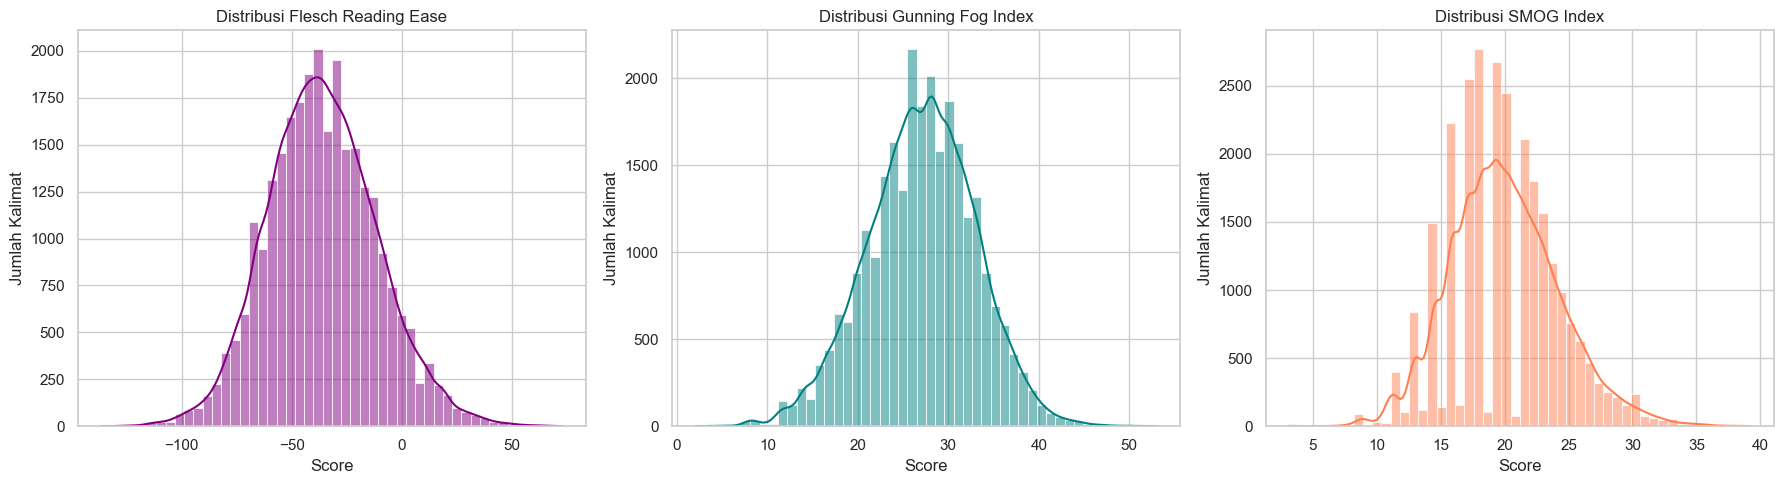

In [50]:
# Distribusi Target (3 Grafik Berbeda)
from IPython.display import display
import seaborn as sns

# ===== DESKRIPSI STATISTIK (Target Readability Scores) =====
print("Deskripsi Statistik Readability Scores:")
display(df[["flesch", "gunning_fog", "smog"]].describe())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Plot Flesch
sns.histplot(df["flesch"], bins=50, kde=True, ax=axes[0], color="purple")
axes[0].set_title("Distribusi Flesch Reading Ease")
axes[0].set_xlabel("Score")
axes[0].set_ylabel("Jumlah Kalimat")

# 2. Plot Gunning Fog
sns.histplot(df["gunning_fog"], bins=50, kde=True, ax=axes[1], color="teal")
axes[1].set_title("Distribusi Gunning Fog Index")
axes[1].set_xlabel("Score")
axes[1].set_ylabel("Jumlah Kalimat")

# 3. Plot SMOG
sns.histplot(df["smog"], bins=50, kde=True, ax=axes[2], color="coral")
axes[2].set_title("Distribusi SMOG Index")
axes[2].set_xlabel("Score")
axes[2].set_ylabel("Jumlah Kalimat")

plt.tight_layout()
plt.show()

